In [226]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/petertroitsky/Desktop/Датасет соц сети (2).csv')

#базовая информация по датасету

print('Размер датасета:', df.shape)
print('\nПризнаки:', df.columns.tolist())

#пропуски

missing = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print('\nПроцент пропусков:\n', missing)

#удаляем признаки с критически высоким уровнем пропусков

df = df.drop(columns=['csat_score'])
df = df.drop_duplicates(subset='id_client')
df = df.dropna(subset=['gender_cd'])

#проверка баланса target

print(
    '\nРаспределение review_mark:\n',
    df['review_mark'].value_counts(normalize=True)*100
)

#проверка cardinality категориальных признаков

cat_cols = [
    'company',
    'product',
    'review_source',
    'segment_name',
    'age_segment',
    'gender_cd'
]

for col in cat_cols:
    print(f'\n{col}: {df[col].nunique()} уникальных значений')

#проверка итогового размера данных

print('\nРазмер датасета после очистки:', df.shape)

df.to_csv('датасет1')


Размер датасета: (56820, 25)

Признаки: ['review_dttm', 'finish_dttm', 'id_client', 'company', 'review_mark', 'review_emotion', 'review_source', 'business_line', 'product', 'reason', 'review_theme', 'subtheme', 'review_text', 'solution_flg', 'gender_cd', 'education_level_cd', 'marital_status_cd', 'children_cnt', 'citizenship_country', 'segment_name', 'subscription_important_flg', 'new_flg', 'influencer_flg', 'age_segment', 'csat_score']

Процент пропусков:
 csat_score                    94.003872
education_level_cd            56.015488
marital_status_cd             33.164379
children_cnt                  23.720521
influencer_flg                23.252376
new_flg                       23.252376
subscription_important_flg    23.252376
segment_name                  23.252376
age_segment                   18.949314
review_text                    3.690602
gender_cd                      0.571982
citizenship_country            0.212953
finish_dttm                    0.165435
review_theme      

Размер датасета: (39988, 25)


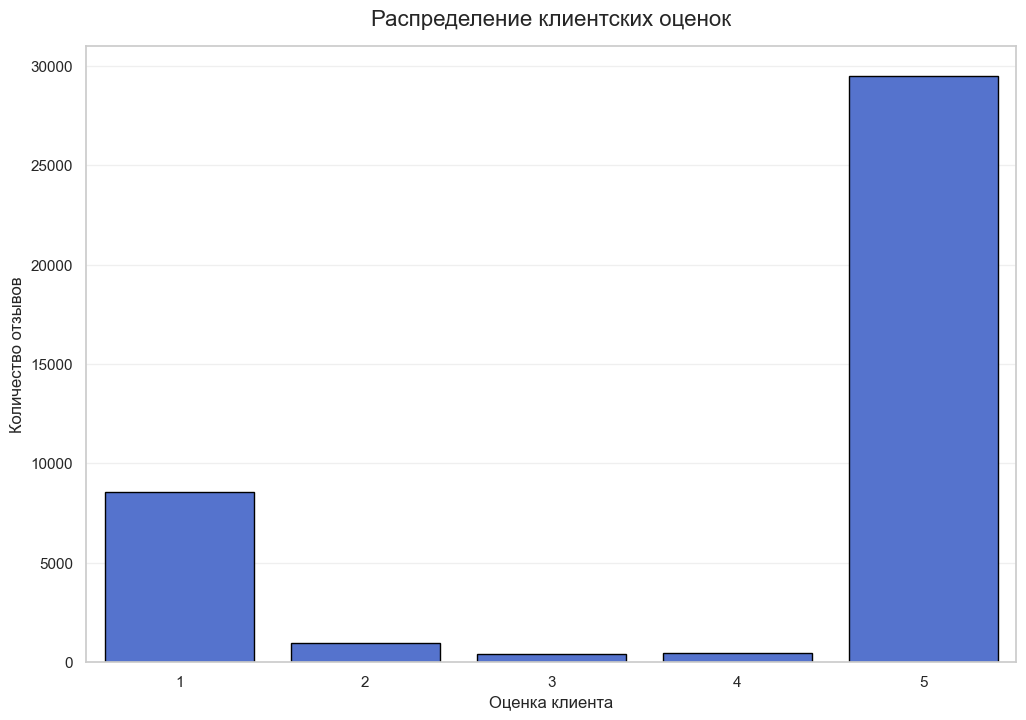

Доля "не указано" в solution_flg: 85.36%


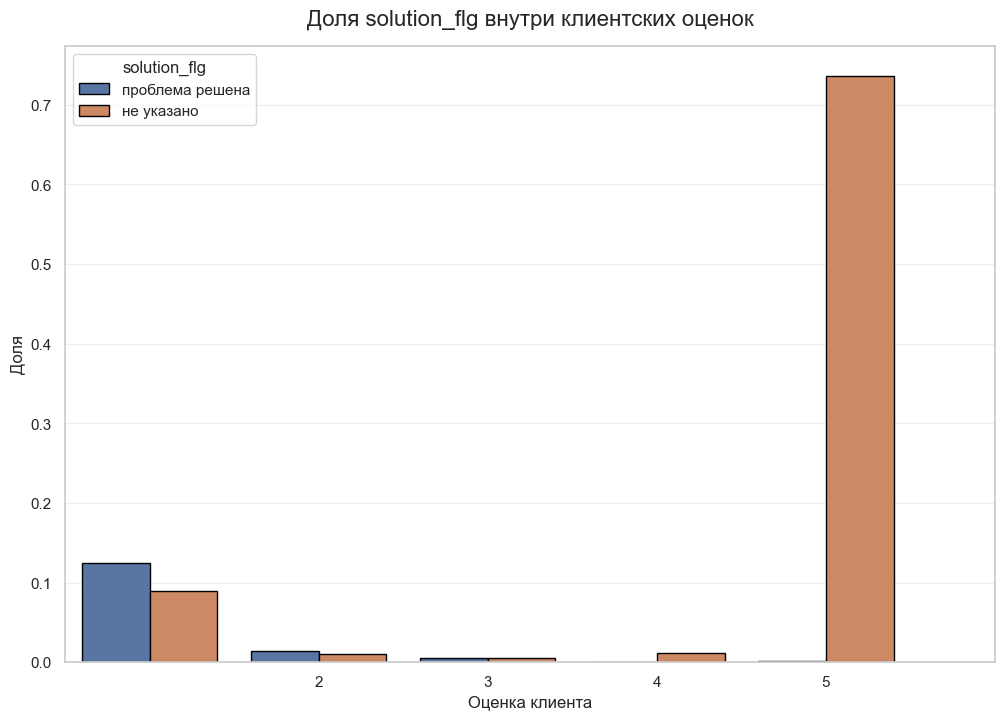

Доля оценок (%):
 review_mark
1    21.47
2     2.44
3     1.09
4     1.22
5    73.78
Name: proportion, dtype: float64
Средняя оценка: 4.03
Медианная оценка: 5.0


In [240]:
# 1. анализируем ключевую переменную review_mark

# оставляем только численные оценки
# анализируем ключевую переменную review_mark

df = pd.read_csv('датасет1')

# оставляем только численные оценки

df = df[
    df['review_mark'].isin(['1', '2', '3', '4', '5'])
].copy()

df['review_mark'] = df['review_mark'].astype(int)

print('Размер датасета:', df.shape)

# распределение оценок

fig, ax = plt.subplots(figsize=(12, 8))

sns.countplot(
    data=df,
    x='review_mark',
    color='royalblue',
    edgecolor='black',
    ax=ax
)

ax.set_title(
    'Распределение клиентских оценок',
    fontsize=16,
    pad=15
)

ax.set_xlabel('Оценка клиента')
ax.set_ylabel('Количество отзывов')

ax.grid(axis='y', alpha=0.3)

plt.show()

# доля solution_flg == "не указано"

missing_solution = (
    (df['solution_flg'] == 'не указано')
    .mean() * 100
)

print(
    f'Доля "не указано" в solution_flg: {missing_solution:.2f}%'
)

# распределение solution_flg внутри review_mark

# фикс ошибки seaborn
df['solution_flg'] = df['solution_flg'].astype(str)

fig, ax = plt.subplots(figsize=(12, 8))

sns.countplot(
    data=df,
    x='review_mark',
    hue='solution_flg',
    stat='probability',
    edgecolor='black',
    ax=ax
)

ax.set_title(
    'Доля solution_flg внутри клиентских оценок',
    fontsize=16,
    pad=15
)

ax.set_xlabel('Оценка клиента')
ax.set_ylabel('Доля')

ax.set_xticks([1, 2, 3, 4, 5])

ax.grid(axis='y', alpha=0.3)

plt.show()

# нормированное распределение оценок

review_dist = (
    df['review_mark']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print(
    'Доля оценок (%):\n',
    review_dist.round(2)
)

# средняя оценка

print(
    'Средняя оценка:',
    round(df['review_mark'].mean(), 2)
)

# медианная оценка

print(
    'Медианная оценка:',
    df['review_mark'].median()
)

df.to_csv('датасет2')


/var/folders/rw/132pz4r15yn3x196g_fsbtmh0000gp/T/ipykernel_8070/745022725.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.countplot(


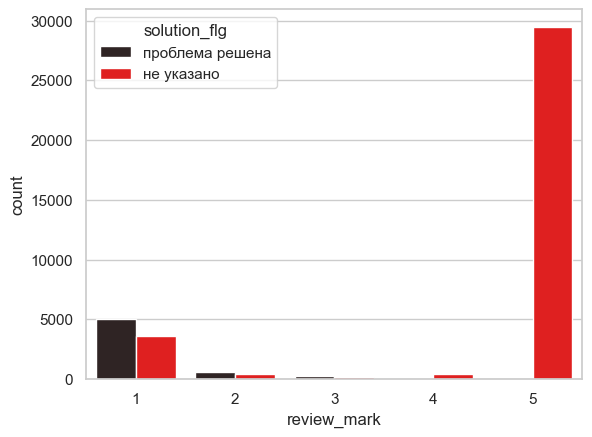

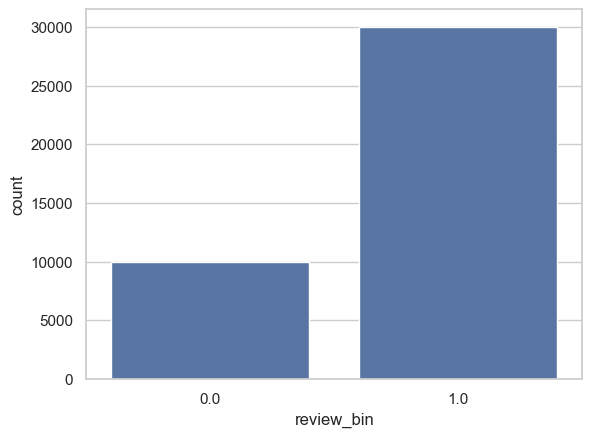

(28266, 27)


In [251]:
df = pd.read_csv('датасет2')

#продолжаем смотреть целевую. наложим фильтр по solution_flg

df2 = df.copy()
df = df[df['review_mark'].isin([1,2,3,4,5])]

sns.countplot(
    data=df,
    x='review_mark',
    hue='solution_flg',
    color='red',
)
plt.show()

#оказывается, что те у кого проблема решена чаще ставят 1, что несколько контринтуитивно. более того, у нас нет флага что проблема не решена.

#хорошо, поскольку у нас нет другой пользоватльской оценки + нам нужно агрегировать тектовые значения в review_mark давайте превратим ее в бин: 0 или 1

data = df.copy()

data.loc[
    data['review_mark'].isin([1, 2, 3, 'без оценки (негативный)', 'без оценки (нейтральный)']),'review_bin'] = 0

data.loc[
    data['review_mark'].isin([4, 5, 'без оценки (позитивный)']), 'review_bin'] = 1

sns.countplot(
    data=data,
    x='review_bin')
plt.show()

#даже несморя на то, что мы засунули в 0 больше фич, все равно есть некий перекос в сторону оценки 5. но с этим теперь можно работать как с бином.

#теперь все наши отзывы распределены на условно "хорошие" и "плохие".
#теперь пропуски. уже на очищенном датасете будут строиться все распределения

data = data.dropna(subset=['gender_cd', 'segment_name', 'age_segment', 'company', 'product', 'review_source', 'influencer_flg'])

data = data[data['age_segment'] != 'Не определен']

print(data.shape)

#мы оставили более половины выборки

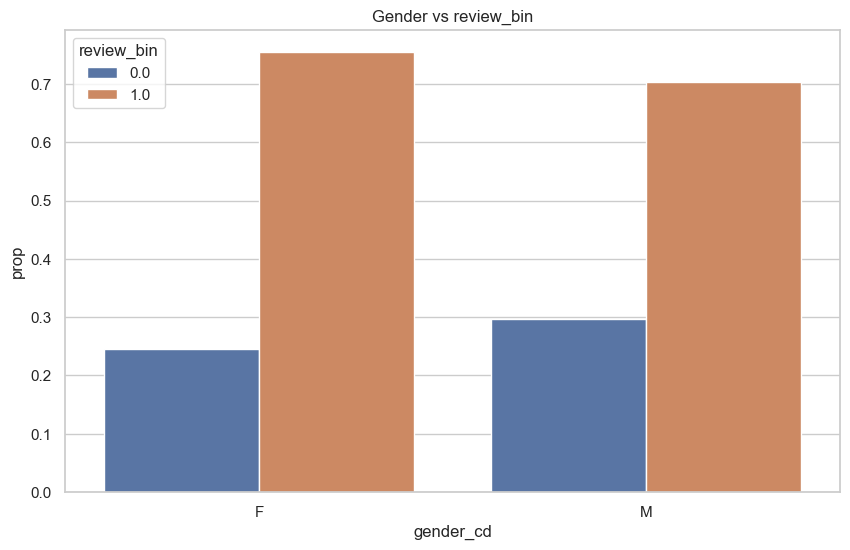

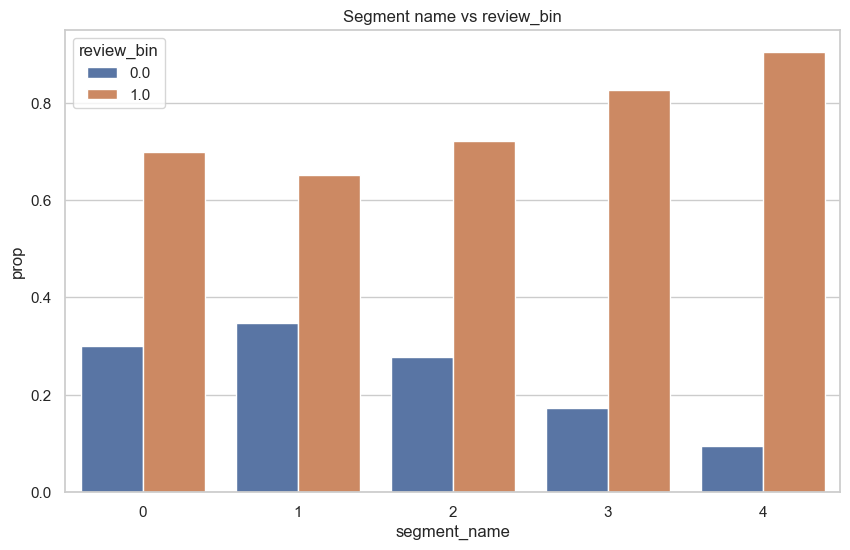

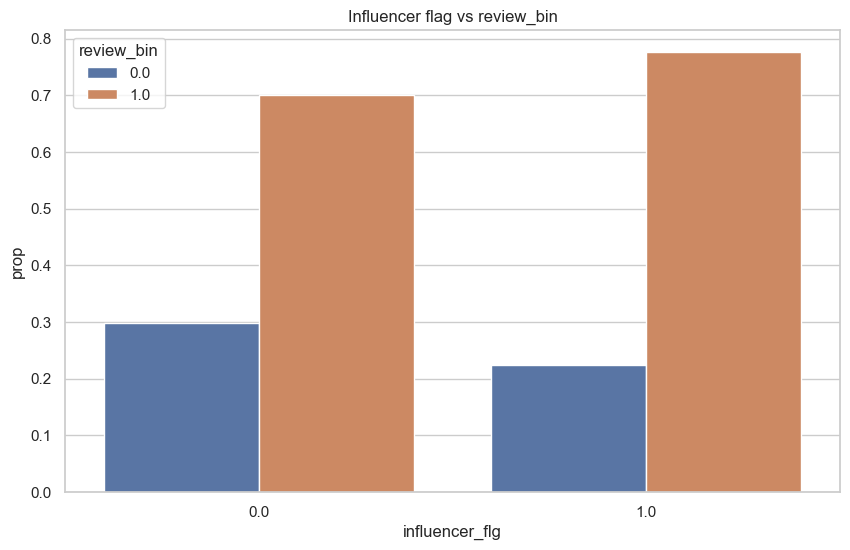

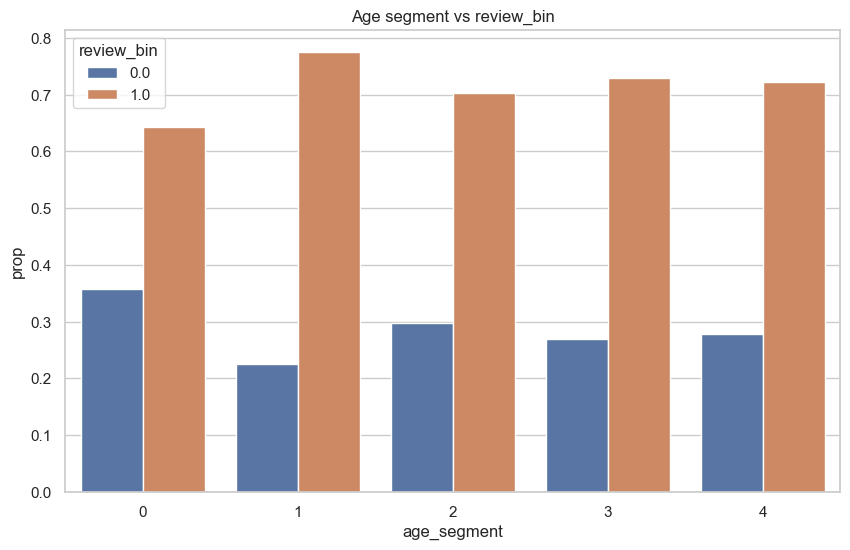

In [252]:
# анализ персональных признаков

data2 = data.copy()

# распределение review_bin по gender_cd
fig, ax = plt.subplots(figsize=(10, 6))

df_plot_gen = (
    data.groupby('gender_cd')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_gen,
    x='gender_cd',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.title('Gender vs review_bin')
plt.show()


# кодирование категориальных признаков рангами
data['segment_name'] = data['segment_name'].replace({
    'Малодоходные': '0',
    'Защищенные': '1',
    'Доходные': '2',
    'Высокодоходные без ПМ': '3',
    'Высокодоходные с ПМ': '4'
})

data['age_segment'] = data['age_segment'].replace({
    'Дети': '0',
    'Подростки': '1',
    'Молодежь': '2',
    'Взрослые': '3',
    'Сеньоры': '4'
})


# распределение review_bin по segment_name
fig, ax = plt.subplots(figsize=(10, 6))

df_plot_seg = (
    data.groupby('segment_name')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_seg,
    x='segment_name',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.title('Segment name vs review_bin')
plt.show()


# распределение review_bin по influencer_flg
fig, ax = plt.subplots(figsize=(10, 6))

df_plot_inf = (
    data.groupby('influencer_flg')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_inf,
    x='influencer_flg',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.title('Influencer flag vs review_bin')
plt.show()


# распределение review_bin по age_segment
fig, ax = plt.subplots(figsize=(10, 6))

df_plot_age = (
    data.groupby('age_segment')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_age,
    x='age_segment',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.title('Age segment vs review_bin')
plt.show()

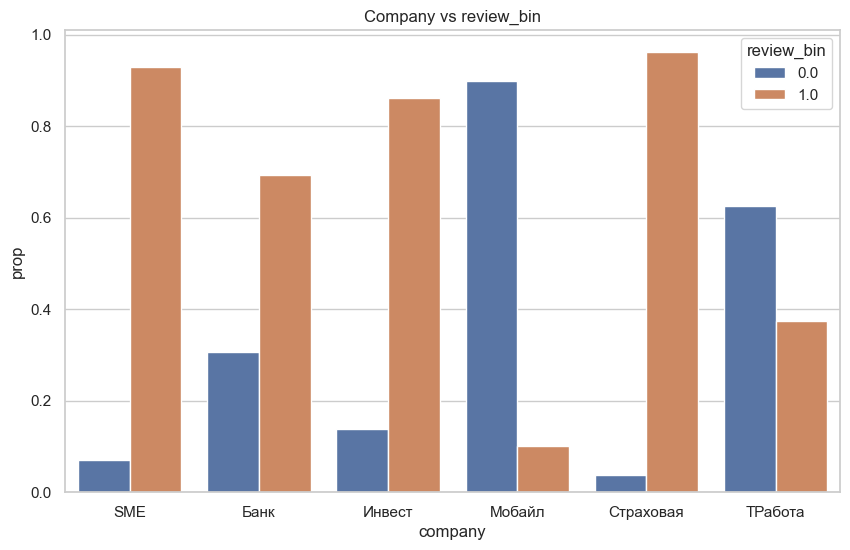

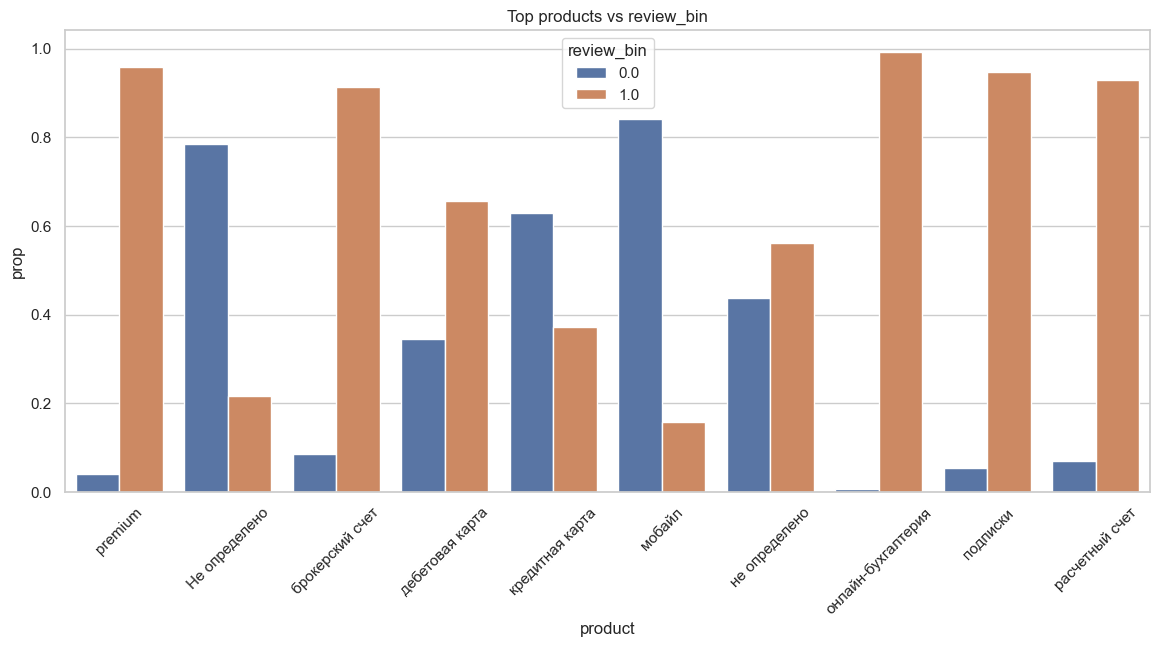

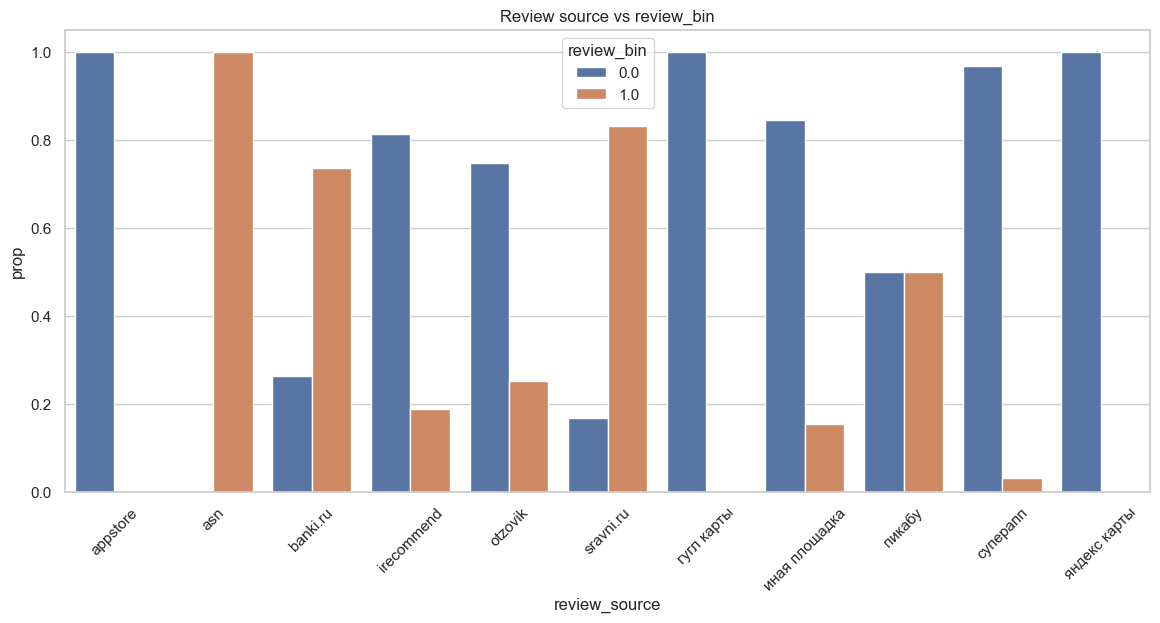

In [259]:
#теперь поработаем с 'продуктовыми' признаками. Это: 'company', 'product', 'review_source'.
#построим их распределения, понаблюдаем за закономерностям

data = data.copy()

#сначала company

# анализ продуктовых признаков

# распределение review_bin по company
fig, ax = plt.subplots(figsize=(10, 6))

df_plot_com = (
    data.groupby('company')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_com,
    x='company',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.title('Company vs review_bin')
plt.show()


# удаляем значение "нет" из product и редкие значения
data = data[data['product'] != 'нет']

valid_products = data['product'].value_counts()
data = data[data['product'].isin(valid_products[valid_products >= 50].index)]

data2 = data.copy()

# распределение review_bin по product
df_plot_prod = (
    data.groupby('product')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

top_products = data['product'].value_counts().head(10).index

fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=df_plot_prod[df_plot_prod['product'].isin(top_products)],
    x='product',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.xticks(rotation=45)
plt.title('Top products vs review_bin')
plt.show()


# распределение review_bin по review_source
fig, ax = plt.subplots(figsize=(14, 6))

df_plot_review = (
    data.groupby('review_source')['review_bin']
    .value_counts(normalize=True)
    .reset_index(name='prop')
)

sns.barplot(
    data=df_plot_review,
    x='review_source',
    y='prop',
    hue='review_bin',
    ax=ax
)

plt.xticks(rotation=45)
plt.title('Review source vs review_bin')
plt.show()

#заметим, что у нас соотношения 0/1 на продуктовых признаков намного более разняться при рассмотрении разных значений этих признаков.

#исходя из этого формулируем гипотезу: вероятность положительного клиентского опыта в большей степени определяется особенностями продукта и типа обращения, чем характеристиками самого клиента.

In [260]:
#пересохраним датасет, чтобы загрузить его  в дальнейший ноутбук

data3 = data2.copy()

data3.to_csv('data3.csv', index=False)